# MMSE 없는 CN · MCI · DEM 분류
### 활동–수면 리듬 특징 + 단일 GroupKFold + 두 관점 CatBoost

**작성 상태: 미실행.** 이 노트북의 학습·특징 추출·시각화 코드는 작성 과정에서 실행하지 않았다. 성능 수치와 주요 특징의 순위는 실제 실행 후에만 결정된다. 목표는 제공 데이터에 맞춘 새로운 분석 파이프라인이며, 기존 논문의 모델이나 성능을 재현했다는 주장은 하지 않는다.

- 분석 단위: **피험자 1명 = 1행**. 반복 일별 기록을 개인별 리듬·분포·변동·활동–수면 결합 특징으로 요약한다.
- 검증: **단일 5-fold GroupKFold**. 중첩 CV는 사용하지 않는다. 피험자 식별자는 그룹 구분에만 쓴다.
- 제외: 인지기능/MMSE CSV는 **읽지 않는다**. MMSE 총점·문항·검사 유무·진단 번호·ID·절대 날짜는 모델 입력에 포함하지 않는다. DIAG_NM은 정답에만 사용한다.
- 주지표: 피험자 단위 **macro-F1**. Accuracy, balanced accuracy, DEM recall, 클래스별 PR/ROC 및 불확실성도 표시한다.
- 특징 선택·결측 필터는 학습 fold 안에서 fit한다. 하이퍼파라미터·앙상블 가중치는 단일 GroupKFold OOF로 선택한다. 별도 early stopping은 사용하지 않는다.
- 공식 Validation은 전체 Training으로 모델을 확정한 뒤 한 번 평가한다. 두 split이 같은 수집원에서 왔으므로 독립 의료기관 외부 검증으로 해석하지 않는다.

**선택한 실행환경: i5-12400 CPU + RTX 3060 GPU, Python 3.11, RAM 16 GB 이상 권장.**
피험자가 적은 표형 데이터에 맞춰 기본 학습은 CPU의 CatBoost Ordered boosting을 사용한다. GPU가 반드시 유리한 규모는 아니다. RTX 3060은 CFG의 task_type='GPU'로 바꾸면 사용할 수 있지만, GPU MultiClass는 Plain boosting만 지원하므로 별도 실행 조건이다. CPU 8 thread, Optuna 1 trial씩 순차 실행해 메모리와 과도한 병렬화를 제한한다. 아래 패키지 설치 셀은 필요할 때 사용자가 실행한다.

기본 설정은 view당 40 trial × 5-fold × 2 views = 400회 탐색 학습, 선택 설정의 3-seed OOF 30회, 최종 학습 6회로 **436회** CatBoost 학습이다. 실행 시간은 측정하지 않았다. n_trials=4는 코드 동작 점검용이다. 최종 성능 탐색에는 기본값 이상을 사용하되, Validation 결과를 확인한 뒤 반복 수정하지 않는다.


In [1]:
from pathlib import Path
import hashlib, json, re, sys, warnings, platform, importlib.metadata
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.special import softmax
from scipy.stats import spearmanr
from sklearn.model_selection import GroupKFold
from sklearn.feature_selection import f_classif
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
    recall_score, log_loss, roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score)
from catboost import CatBoostClassifier, Pool
import optuna, shap, joblib

CFG = dict(
    seed=2026, n_splits=5, n_trials=40, seeds=[2026,2037,2048],
    thread_count=8, task_type='CPU',
    observation_days=None, min_days=7, csv_chunksize=256,
    shap_max_subjects=200, bootstrap_repeats=2000,
    permutation_repeats=10,
)
# 프로젝트 폴더, '128.치매 고위험군 라이프로그', '01.데이터', 또는 영문 Data 경로.
# 자동 탐지가 실패하면 예: DATA_ROOT = Path('/your/path/128.치매 고위험군 라이프로그/01.데이터')
DATA_ROOT = None
CLASS_NAMES = ['CN', 'MCI', 'DEM']
LABEL_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}
np.random.seed(CFG['seed'])
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi':110, 'axes.unicode_minus':False})
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Python:', sys.version.split()[0], '|', platform.system(), '| task_type:', CFG['task_type'])
display(pd.Series({p: importlib.metadata.version(p) for p in
    ['numpy','pandas','scikit-learn','catboost','optuna','shap']}, name='version'))


/Users/pig30nidae/Pig30nidaE/Project/3-class/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.12.8 | Darwin | task_type: CPU


numpy           1.26.4
pandas           2.2.3
scikit-learn     1.6.1
catboost         1.2.8
optuna           4.5.0
shap            0.48.0
Name: version, dtype: object

## 1. 데이터 구조와 고정된 분석 규칙

작성 전 CSV 구조를 읽기 전용으로 확인한 결과다. 아래 실행 셀은 현재 파일에서 다시 검사한다.

| split | 활동 행 | 수면 행 | 피험자 | CN | MCI | DEM |
|---|---:|---:|---:|---:|---:|---:|
| Training | 9,705 | 9,705 | 141 | 85 | 47 | 9 |
| Validation | 2,478 | 2,478 | 33 | 26 | 4 | 3 |

- 원천 ID는 EMAIL, 라벨 ID는 SAMPLE_EMAIL, 진단명은 DIAG_NM이다. Dem은 DEM으로 표준화한다. 현재 split 간 피험자 중복은 0명이다.
- 원래 시퀀스 열에는 '...'가 있고, 실제 값은 CONVERT(... USING utf8) 열에 '/' 구분으로 저장돼 있다. 활동 MET는 1분, 활동 상태와 수면 시퀀스는 5분 간격 필드다.
- 수면은 기상 날짜 기준 같은 피험자의 중복 기록이 Training 11건, Validation 1건 있다. sleep_is_longest가 모두 1이므로 이것만으로 제거할 수 없다. **같은 기상 날짜의 가장 긴 sleep_duration**, 동률이면 이른 취침을 선택한다. 추가 수면 세션은 합산하지 않는다.
- 활동 날짜는 activity_day_start의 한국 현지 날짜, 수면 날짜는 sleep_bedtime_end의 현지 날짜다. 당일/다음날 결합을 구분하며, 행 순서나 피험자 ID만으로 합치지 않는다.
- 기본은 개인별 **제공된 전체 관측기간**을 활용해 정보 손실을 줄인다. 관측 날짜 합계 7일 이상인 사람을 분석하며 실제 제외 인원을 출력한다. 같은 관측기간 비교가 필요하면 실행 전에 observation_days=60으로 고정할 수 있다. 이는 첫 60개 기록이 아니라 첫 관측일부터 60 calendar days를 뜻한다. 기본 모델은 관측기간 종료 후 분류하며 미래 발병 예측이 아니다.
- HR/RMSSD의 0은 유효 생리값에서 제외한다. 시퀀스 위치는 유지하여 결측 구간을 가로질러 변화량을 만들지 않는다. 수면 상태 코드는 코드북이 제공되지 않았으므로 의미를 임의 지정하지 않고 code_1 등의 중립적 특징으로 쓴다.
- 실제 독립 표본은 141명이다. DEM 9명 및 holdout DEM 3명에서 점수의 변동이 클 수 있으므로 피험자 bootstrap 구간과 클래스별 표본 수를 함께 해석한다.


In [2]:
def resolve_paths(root=None):
    bases = [Path(root)] if root is not None else [Path.cwd(), Path('/content')]
    candidates=[]
    for base in bases:
        candidates.extend([base, base/'01.데이터', base/'128.치매 고위험군 라이프로그'/'01.데이터', base/'Data'])
    for base in candidates:
        for source_dir, label_dir, act_dir, sleep_dir in [
            ('원천데이터','라벨링데이터','1.걸음걸이','2.수면'),
            ('SourceData','LabelingData','1.Gait','2.Sleep')]:
            result={}
            for split, folder, prefix in [('train','1.Training','train'),('val','2.Validation','val')]:
                label_file = 'training_label.csv' if split=='train' else 'val_label.csv'
                result[split] = {
                    'activity':base/folder/source_dir/act_dir/f'{prefix}_activity.csv',
                    'sleep':base/folder/source_dir/sleep_dir/f'{prefix}_sleep.csv',
                    'activity_label':base/folder/label_dir/act_dir/label_file,
                    'sleep_label':base/folder/label_dir/sleep_dir/label_file,
                }
            if all(p.is_file() for split in result.values() for p in split.values()):
                return base.resolve(), result
    raise FileNotFoundError('DATA_ROOT를 데이터 폴더로 지정하세요. 활동/수면/두 라벨 CSV만 검색합니다.')

ROOT, PATHS = resolve_paths(DATA_ROOT)
assert all('mmse' not in str(p).lower() for d in PATHS.values() for p in d.values())
print('선택한 데이터 루트:', ROOT)
print('원본 폴더와 영문 Data 복사본을 합치지 않습니다.')

def subject_key(value):
    text = str(value).strip().lower()
    if not text or text in {'nan','none','<na>'}:
        raise ValueError('비어 있는 피험자 ID가 있습니다.')
    return hashlib.sha256(text.encode('utf-8')).hexdigest()

def read_labels(paths):
    tables=[]
    for name in ['activity_label','sleep_label']:
        t=pd.read_csv(paths[name], dtype=str, encoding='utf-8-sig',
                      usecols=['SAMPLE_EMAIL','DIAG_NM'])
        t['subject']=t['SAMPLE_EMAIL'].map(subject_key)
        t['label']=t['DIAG_NM'].str.strip().str.upper()
        if t['label'].isna().any() or not t['label'].isin(CLASS_NAMES).all():
            raise ValueError('허용되지 않은 라벨/빈 라벨이 있습니다.')
        tables.append(t[['subject','label']])
    labels=pd.concat(tables, ignore_index=True)
    conflicts=labels.groupby('subject')['label'].nunique().gt(1)
    if conflicts.any():
        raise ValueError(f'진단이 충돌하는 피험자 {conflicts.sum()}명: 시점 정보 확인 전 학습 중단.')
    return labels.drop_duplicates('subject').set_index('subject')['label']

train_labels=read_labels(PATHS['train'])
val_labels=read_labels(PATHS['val'])
overlap = train_labels.index.intersection(val_labels.index)
if len(overlap) and not train_labels.loc[overlap].equals(val_labels.loc[overlap]):
    raise ValueError('split 사이에 진단이 다른 동일 피험자가 있습니다. 별도 종단 설계가 필요합니다.')
# 중복이 있으면 Validation 피험자 전체를 제외하며 Training으로 이동시키지 않는다.
val_labels=val_labels.drop(overlap)
print('Validation에서 제외한 Training 중복 피험자 수:', len(overlap))
display(pd.DataFrame({'Training':train_labels.value_counts(),
                      'Validation':val_labels.value_counts()}).reindex(CLASS_NAMES).fillna(0).astype(int))


선택한 데이터 루트: /Users/pig30nidae/Pig30nidaE/Project/3-class/128.치매 고위험군 라이프로그/01.데이터
원본 폴더와 영문 Data 복사본을 합치지 않습니다.
Validation에서 제외한 Training 중복 피험자 수: 0


,Training,Validation
label,,
CN,85,26
MCI,47,4
DEM,9,3


## 2. 특징 추출: 개인 내부 계산만 수행

일별 요약값의 중앙값·IQR·10/90 분위수에 더해 연속된 날의 변동성, 개인 내부 추세, MET의 24시간 주기·활동 집중도, 상태 전환·연속 구간, 심박/HRV 변동, 취침·기상 시각의 원형 표현을 만든다. 수면/활동을 같은 날짜 및 정확히 다음 날짜로 연결한 상관도 포함한다.

관측 수·결측률·비착용·시퀀스 길이는 quality, 제조사 score는 vendor로 표기한다. 전체 view와 quality/vendor를 제거한 physiology view를 안쪽 교차검증에서 비교한다. quality가 예측에 유용하더라도 생물학적 원인으로 해석하지 않는다. 특징 정의는 라벨을 사용하지 않으며, 전체 집단에 대한 통계적 전처리와 특징 선택은 이 단계에서 하지 않는다.


In [3]:
ACT_NUM = [
 'activity_average_met','activity_cal_active','activity_cal_total','activity_daily_movement',
 'activity_high','activity_inactive','activity_inactivity_alerts','activity_low','activity_medium',
 'activity_met_min_high','activity_met_min_inactive','activity_met_min_low','activity_met_min_medium',
 'activity_non_wear','activity_rest','activity_score','activity_score_meet_daily_targets',
 'activity_score_move_every_hour','activity_score_recovery_time','activity_score_stay_active',
 'activity_score_training_frequency','activity_score_training_volume','activity_steps','activity_total']
SLEEP_NUM = [
 'sleep_awake','sleep_breath_average','sleep_deep','sleep_duration','sleep_efficiency',
 'sleep_hr_average','sleep_hr_lowest','sleep_light','sleep_onset_latency','sleep_rem',
 'sleep_restless','sleep_rmssd','sleep_score','sleep_score_alignment','sleep_score_deep',
 'sleep_score_disturbances','sleep_score_efficiency','sleep_score_latency','sleep_score_rem',
 'sleep_score_total','sleep_temperature_delta','sleep_temperature_deviation','sleep_total']
SEQ_COLS = {
 'activity': {'state':'CONVERT(activity_class_5min USING utf8)', 'met':'CONVERT(activity_met_1min USING utf8)'},
 'sleep': {'hr':'CONVERT(sleep_hr_5min USING utf8)', 'state':'CONVERT(sleep_hypnogram_5min USING utf8)',
           'hrv':'CONVERT(sleep_rmssd_5min USING utf8)'}}
# 절대 날짜는 날짜 결합 / 개인 내 추세 계산 전용이며 모델에 직접 입력하지 않는다.
TIME_COLS = {'activity':['activity_day_start','activity_day_end'],
             'sleep':['sleep_bedtime_start','sleep_bedtime_end']}
DAILY_META={}
AUDIT=[]

def register(name, modality, family='physiology', description=''):
    DAILY_META[name]={'modality':modality,'family':family,'description':description or name}
    return name

def number(value):
    try:
        x=float(value)
        return x if np.isfinite(x) else np.nan
    except (ValueError,TypeError):
        return np.nan

def divide(a,b):
    return a/b if np.isfinite(a) and np.isfinite(b) and b>0 else np.nan

def parse_sequence(value, positive_only=False):
    if value is None or str(value).strip() in {'','nan','...','None'}:
        return np.array([],dtype=float)
    tokens=str(value).strip().split('/')
    # 끝부분 slash의 빈 token만 제거하고 내부 빈 token은 NaN으로 위치를 보존한다.
    while tokens and not tokens[-1].strip():
        tokens.pop()
    arr=np.array([number(x) for x in tokens],dtype=float)
    if positive_only:
        arr[arr<=0]=np.nan
    return arr

def safe_corr(a,b,min_n=4):
    a,b=np.asarray(a,float),np.asarray(b,float)
    good=np.isfinite(a)&np.isfinite(b)
    if good.sum()<min_n or np.std(a[good])==0 or np.std(b[good])==0:
        return np.nan
    return float(np.corrcoef(a[good],b[good])[0,1])

def continuous_stats(a):
    good=a[np.isfinite(a)]
    out={k:np.nan for k in ['mean','std','p10','p90','rmssd_adjacent','lag1','last_first_third']}
    if len(good):
        out.update(mean=float(np.mean(good)),std=float(np.std(good)),
                   p10=float(np.quantile(good,.1)),p90=float(np.quantile(good,.9)))
    if len(a)>1:
        d=np.diff(a); d=d[np.isfinite(d)]
        out['rmssd_adjacent']=float(np.sqrt(np.mean(d*d))) if len(d) else np.nan
        out['lag1']=safe_corr(a[:-1],a[1:])
    third=len(a)//3
    if third and np.isfinite(a[:third]).any() and np.isfinite(a[-third:]).any():
        out['last_first_third']=float(np.nanmean(a[-third:])-np.nanmean(a[:third]))
    return out

def categorical_stats(a,states):
    valid=np.isfinite(a)&np.isin(a,states)
    out={}
    probabilities=[]
    for state in states:
        p=float(np.sum(valid & (a==state))/valid.sum()) if valid.any() else np.nan
        out[f'code_{state}_fraction']=p
        probabilities.append(p)
        lengths=[]; run=0
        for x in a:
            if np.isfinite(x) and x==state:
                run+=1
            elif run:
                lengths.append(run); run=0
        if run: lengths.append(run)
        out[f'code_{state}_longest_minutes']=max(lengths,default=0)*5 if valid.any() else np.nan
    probabilities=np.array(probabilities)
    positive=probabilities[np.isfinite(probabilities)&(probabilities>0)]
    out['entropy']=float(-np.sum(positive*np.log(positive))) if len(positive) else np.nan
    pair=valid[:-1]&valid[1:]
    out['transition_rate']=float(np.mean(a[:-1][pair]!=a[1:][pair])) if pair.any() else np.nan
    return out

def local_timestamp(value):
    t=pd.to_datetime(value,errors='coerce')
    if pd.isna(t): return pd.NaT
    return t.tz_localize('Asia/Seoul') if t.tzinfo is None else t.tz_convert('Asia/Seoul')

def clock_hours(t):
    return t.hour+t.minute/60+t.second/3600 if pd.notna(t) else np.nan

def met_clock_features(a,start_hour):
    # 시퀀스 길이를 24시간으로 강제 보간하지 않고 실제 1분 위치를 사용한다.
    out={}; profile=np.full(24,np.nan)
    hours=(start_hour+np.arange(len(a))/60)%24
    valid=np.isfinite(a)&(a>=0)
    if np.isfinite(start_hour) and valid.sum()>=720 and len(np.unique(np.floor(hours[valid])))>=18:
        for h in range(24):
            mask=valid & (np.floor(hours)==h)
            if mask.sum()>=30: profile[h]=np.mean(a[mask])
        t=2*np.pi*hours[valid]/24
        design=np.column_stack([np.ones(len(t)),np.cos(t),np.sin(t)])
        beta=np.linalg.lstsq(design,a[valid],rcond=None)[0]
        amplitude=float(np.hypot(beta[1],beta[2]))
        out.update(cosinor_amplitude=amplitude,
                   cosinor_relative_amplitude=divide(amplitude,abs(beta[0])),
                   cosinor_phase_cos=divide(beta[1],amplitude),
                   cosinor_phase_sin=divide(beta[2],amplitude))
        day=valid&(hours>=8)&(hours<20)
        night=valid&((hours<8)|(hours>=20))
        out['day_night_difference']=float(np.mean(a[day])-np.mean(a[night])) if day.any() and night.any() else np.nan
    else:
        out.update({k:np.nan for k in ['cosinor_amplitude','cosinor_relative_amplitude',
                    'cosinor_phase_cos','cosinor_phase_sin','day_night_difference']})
    windows={}
    for width,name in [(5,'low5'),(10,'high10')]:
        rolled=np.r_[profile,profile[:width-1]]
        values=[np.mean(rolled[i:i+width]) for i in range(24)
                if np.isfinite(rolled[i:i+width]).all()]
        windows[name]=(min(values) if width==5 else max(values)) if values else np.nan
    out['relative_high10_low5']=divide(windows['high10']-windows['low5'],
                                                windows['high10']+windows['low5'])
    out['low5_met']=windows['low5']; out['high10_met']=windows['high10']
    return out,profile

def extract_day(row,modality):
    out={'subject':subject_key(row['EMAIL'])}
    start=local_timestamp(row[TIME_COLS[modality][0]])
    end=local_timestamp(row[TIME_COLS[modality][1]])
    day=start if modality=='activity' else end
    out['_date']=day.normalize().tz_localize(None) if pd.notna(day) else pd.NaT
    out['_start']=start
    numeric=ACT_NUM if modality=='activity' else SLEEP_NUM
    for col in numeric:
        value=number(row.get(col))
        if 'temperature' not in col and np.isfinite(value) and value<0: value=np.nan
        if col in {'sleep_hr_average','sleep_hr_lowest','sleep_rmssd','sleep_breath_average'} and value==0:
            value=np.nan
        family='vendor' if 'score' in col else ('quality' if 'non_wear' in col else 'physiology')
        name=modality+'__'+col.removeprefix(modality+'_')
        out[register(name,modality,family,col)]=value
    for key,column in SEQ_COLS[modality].items():
        seq=parse_sequence(row.get(column),positive_only=key in {'hr','hrv'})
        if key=='met': seq[seq<0]=np.nan
        if key=='state':
            states=range(6) if modality=='activity' else range(1,5)
            seq[~np.isin(seq,list(states))]=np.nan
            stats=categorical_stats(seq,list(states))
        else:
            stats=continuous_stats(seq)
        for stat,value in stats.items():
            name=f'{modality}__{key}_{stat}'
            out[register(name,modality,description=f'{column}: {stat}')]=value
        for stat,value in [('valid_fraction',np.isfinite(seq).mean() if len(seq) else 0),('length',len(seq))]:
            name=f'{modality}__{key}_{stat}'
            out[register(name,modality,'quality',f'{column}: {stat}')]=value
        if modality=='activity' and key=='met':
            met,profile=met_clock_features(seq,clock_hours(start))
            for stat,value in met.items():
                out[register('activity__met_'+stat,modality,description='MET clock: '+stat)]=value
            out.update({f'_hour_{h:02d}':v for h,v in enumerate(profile)})
    if modality=='activity':
        nonwear=out['activity__non_wear']
        interval_minutes=(end-start).total_seconds()/60 if pd.notna(end) and pd.notna(start) else np.nan
        # activity_day_end는 마지막 1초 직전이므로 약 1440분인 경우만 24시간으로 간주한다.
        full_day=np.isfinite(interval_minutes) and abs(interval_minutes-1440)<1
        wear=1440-nonwear if full_day and np.isfinite(nonwear) and 0<=nonwear<=1440 else np.nan
        out[register('activity__interval_minutes',modality,'quality')]=interval_minutes
        derived={
            'steps_per_wear_hour':divide(out['activity__steps'],wear/60),
            'moderate_high_fraction':divide(out['activity__medium']+out['activity__high'],wear),
            'inactive_fraction':divide(out['activity__inactive'],wear),
        }
    else:
        total=out['sleep__total']; duration=out['sleep__duration']
        derived={name+'_fraction':divide(out['sleep__'+name],total) for name in ['deep','light','rem']}
        derived.update(awake_fraction=divide(out['sleep__awake'],duration),
                       latency_fraction=divide(out['sleep__onset_latency'],duration))
        # 자정 경계의 불연속을 피하기 위한 원형 시각 특징.
        for name,timestamp in [('bedtime',start),('wake',end)]:
            phase=2*np.pi*clock_hours(timestamp)/24
            derived[name+'_sin']=np.sin(phase); derived[name+'_cos']=np.cos(phase)
    for name,value in derived.items():
        out[register(modality+'__'+name,modality,description=name)]=value
    return out

def load_daily(path,modality,split):
    allowed=['EMAIL']+(ACT_NUM if modality=='activity' else SLEEP_NUM)+TIME_COLS[modality]+list(SEQ_COLS[modality].values())
    header=pd.read_csv(path,nrows=0,encoding='utf-8-sig').columns
    missing=set(allowed)-set(header)
    if missing: raise ValueError(f'{modality} 필수 열 누락: {sorted(missing)}')
    records=[]; input_rows=0
    for chunk in pd.read_csv(path,dtype=str,encoding='utf-8-sig',usecols=allowed,chunksize=CFG['csv_chunksize']):
        input_rows+=len(chunk)
        records.extend(extract_day(row,modality) for row in chunk.to_dict('records'))
    frame=pd.DataFrame.from_records(records)
    bad_dates=int(frame['_date'].isna().sum())
    frame=frame.dropna(subset=['_date'])
    if modality=='sleep':
        frame=frame.sort_values(['subject','_date','sleep__duration','_start'],
                    ascending=[True,True,False,True],na_position='last',kind='stable')
    else:
        frame=frame.sort_values(['subject','_date','_start'],kind='stable')
    duplicate=int(frame.duplicated(['subject','_date']).sum())
    frame=frame.drop_duplicates(['subject','_date'],keep='first').drop(columns=['_start'])
    AUDIT.append(dict(split=split,modality=modality,input_rows=input_rows,
                      bad_dates=bad_dates,duplicate_subject_dates=duplicate,kept_rows=len(frame),
                      subjects=frame['subject'].nunique()))
    assert not frame.duplicated(['subject','_date']).any()
    return frame.sort_values(['subject','_date']).reset_index(drop=True)


In [4]:
FEATURE_META_RECORDS={}
AGG_STATS=['median','iqr','p10','p90']
TEMPORAL_KEYS = {
 'activity':['activity__steps','activity__average_met','activity__inactive','activity__met_cosinor_amplitude',
             'activity__met_relative_high10_low5'],
 'sleep':['sleep__total','sleep__efficiency','sleep__hr_average','sleep__rmssd',
          'sleep__awake_fraction','sleep__deep_fraction','sleep__rem_fraction']}

def add_subject_feature(out,name,value,modality,family='physiology',description=''):
    out[name]=float(value) if np.isfinite(value) else np.nan
    FEATURE_META_RECORDS[name]={'modality':modality,'family':family,'description':description or name}

def observation_window(activity,sleep):
    both=pd.concat([activity[['subject','_date']],sleep[['subject','_date']]]).drop_duplicates()
    start=both.groupby('subject')['_date'].min()
    result=[]
    for frame in [activity,sleep]:
        elapsed=(frame['_date']-frame['subject'].map(start)).dt.days
        mask=elapsed.ge(0)
        if CFG['observation_days'] is not None:
            mask &= elapsed.lt(CFG['observation_days'])
        result.append(frame.loc[mask].copy())
    days=pd.concat([x[['subject','_date']] for x in result]).drop_duplicates().groupby('subject').size()
    eligible=days.index[days>=CFG['min_days']]
    return [x[x['subject'].isin(eligible)].copy() for x in result], days

def summarize_modality(frame,subject,modality,out):
    g=frame[frame['subject']==subject].sort_values('_date')
    for col,meta in DAILY_META.items():
        if meta['modality']!=modality: continue
        a=g[col].to_numpy(float) if col in g else np.array([],float)
        finite=a[np.isfinite(a)]
        vals=[np.median(finite),np.quantile(finite,.75)-np.quantile(finite,.25),
              np.quantile(finite,.1),np.quantile(finite,.9)] if len(finite) else [np.nan]*4
        for stat,value in zip(AGG_STATS,vals):
            add_subject_feature(out,col+'__'+stat,value,modality,meta['family'],meta['description']+'; across days '+stat)
        add_subject_feature(out,col+'__missing_fraction',1-len(finite)/len(a) if len(a) else 1,
                            modality,'quality',meta['description']+'; daily missing fraction')
    span=(g['_date'].max()-g['_date'].min()).days+1 if len(g) else 0
    for stat,value in [('n_days',len(g)),('span_days',span),('coverage',divide(len(g),span))]:
        add_subject_feature(out,f'{modality}__quality_{stat}',value,modality,'quality',stat)
    for col in TEMPORAL_KEYS[modality]:
        values=g[col].to_numpy(float) if col in g else np.array([],float)
        times=(g['_date']-g['_date'].min()).dt.days.to_numpy(float) if len(g) else np.array([],float)
        good=np.isfinite(values)
        adjacent=(np.diff(times)==1)&np.isfinite(np.diff(values))
        delta=np.diff(values)[adjacent]
        rmssd=np.sqrt(np.mean(delta**2)) if len(delta) else np.nan
        slope=np.polyfit(times[good],values[good],1)[0] if good.sum()>=4 and np.ptp(times[good])>0 else np.nan
        lag=safe_corr(values[:-1][adjacent],values[1:][adjacent]) if len(values)>1 else np.nan
        for stat,value in [('day_rmssd',rmssd),('trend_per_day',slope),('consecutive_lag1',lag)]:
            add_subject_feature(out,col+'__'+stat,value,modality,description=col+'; '+stat)
    # 일별 시간대 profile의 전체 분산 중 시간대 평균으로 설명되는 비율.
    if modality=='activity':
        hourly=g[[f'_hour_{h:02d}' for h in range(24)]].to_numpy(float) if len(g) else np.empty((0,24))
        valid=np.isfinite(hourly)
        if valid.sum()>48 and np.nanvar(hourly)>0:
            sums=np.nansum(hourly,axis=0); counts=valid.sum(axis=0)
            profile=np.divide(sums,counts,out=np.full(24,np.nan),where=counts>0)
            overall=np.nanmean(hourly)
            between=np.nansum(counts*(profile-overall)**2)
            total=np.nansum((hourly-overall)**2)
            stability=divide(between,total)
        else: stability=np.nan
        add_subject_feature(out,'activity__hourly_profile_stability',stability,modality,
                            description='분산 가중 시간대 반복성; 표준 actigraphy IS와 동일한 지표라고 주장하지 않음')
    if modality=='sleep':
        for phase in ['bedtime','wake']:
            a=g[f'sleep__{phase}_sin'].to_numpy(float) if len(g) else np.array([])
            b=g[f'sleep__{phase}_cos'].to_numpy(float) if len(g) else np.array([])
            mask=np.isfinite(a)&np.isfinite(b)
            strength=np.hypot(a[mask].mean(),b[mask].mean()) if mask.any() else np.nan
            add_subject_feature(out,f'sleep__{phase}_regularity',strength,modality,
                                description='시각 원형 resultant length: 1에 가까울수록 규칙적')

def summarize_coupling(activity,sleep,subject,out):
    a=activity[activity['subject']==subject]
    s=sleep[sleep['subject']==subject]
    # activity date d ↔ wake date d / wake date d+1. 같은 개인 안에서만 결합.
    pairs=[('activity__steps','sleep__total'),('activity__steps','sleep__efficiency'),
           ('activity__average_met','sleep__rmssd'),('activity__inactive','sleep__awake_fraction')]
    for shift,title in [(0,'same_wake_day'),(1,'next_wake_day')]:
        aa=a.copy(); aa['_date']=aa['_date']+pd.Timedelta(days=shift)
        joined=aa.merge(s,on=['subject','_date'],how='inner',validate='one_to_one')
        add_subject_feature(out,f'coupling__{title}_n_pairs',len(joined),'coupling','quality',title+' paired days')
        for ac,sc in pairs:
            corr=safe_corr(joined[ac],joined[sc],min_n=7) if len(joined) else np.nan
            name=f'coupling__{title}__{ac.removeprefix("activity__")}__{sc.removeprefix("sleep__")}_corr'
            add_subject_feature(out,name,corr,'coupling',description=f'{ac} vs {sc}; {title}; Pearson r, min 7 paired days')

def build_subjects(activity,sleep):
    (activity,sleep),all_days=observation_window(activity,sleep)
    subjects=sorted(set(activity['subject'])|set(sleep['subject']))
    rows=[]
    for subject in subjects:
        out={'subject':subject}
        summarize_modality(activity,subject,'activity',out)
        summarize_modality(sleep,subject,'sleep',out)
        summarize_coupling(activity,sleep,subject,out)
        rows.append(out)
    if not rows: raise ValueError('최소 관측일 기준을 만족하는 피험자가 없습니다.')
    features=pd.DataFrame(rows).set_index('subject').sort_index()
    features=features.replace([np.inf,-np.inf],np.nan).astype('float32')
    assert features.index.is_unique and features.columns.is_unique
    return features, activity, sleep, all_days

train_activity=load_daily(PATHS['train']['activity'],'activity','Training')
train_sleep=load_daily(PATHS['train']['sleep'],'sleep','Training')
val_activity=load_daily(PATHS['val']['activity'],'activity','Validation')
val_sleep=load_daily(PATHS['val']['sleep'],'sleep','Validation')
display(pd.DataFrame(AUDIT))
for split,activity,sleep,labels in [('Training',train_activity,train_sleep,train_labels),
                                  ('Validation',val_activity,val_sleep,val_labels)]:
    source_subjects=set(activity['subject'])|set(sleep['subject'])
    print(split, '라벨 없는 원천 피험자:',len(source_subjects-set(labels.index)),
          '| 원천 없는 라벨 피험자:',len(set(labels.index)-source_subjects))
# 라벨 없는 사람 및 Training과 겹치는 Validation 사람은 전체 기록을 제외.
train_activity=train_activity[train_activity['subject'].isin(train_labels.index)]
train_sleep=train_sleep[train_sleep['subject'].isin(train_labels.index)]
val_activity=val_activity[val_activity['subject'].isin(val_labels.index)]
val_sleep=val_sleep[val_sleep['subject'].isin(val_labels.index)]
X_train,train_activity,train_sleep,train_days=build_subjects(train_activity,train_sleep)
FEATURE_META=pd.DataFrame.from_dict(FEATURE_META_RECORDS,orient='index').loc[X_train.columns]
if len(val_activity) or len(val_sleep):
    X_holdout,val_activity,val_sleep,val_days=build_subjects(val_activity,val_sleep)
    X_holdout=X_holdout.reindex(columns=X_train.columns)
else:
    X_holdout=pd.DataFrame(columns=X_train.columns,dtype='float32')
y_train=train_labels.reindex(X_train.index).map(LABEL_MAP).to_numpy(dtype=int)
y_holdout=val_labels.reindex(X_holdout.index).map(LABEL_MAP).to_numpy(dtype=int)
groups_train=X_train.index.to_numpy()
assert set(X_train.index).isdisjoint(X_holdout.index)
assert set(y_train)=={0,1,2}
assert all(c.startswith(('activity__','sleep__','coupling__')) for c in X_train.columns)
assert not any(re.search(r'mmse|diag|email|doctor|sample|_date|q[0-9]',c,re.I) for c in X_train.columns)
assert not X_train.select_dtypes(exclude='number').columns.size
print('최종 Training:',X_train.shape,'| Validation:',X_holdout.shape)
print('관측일 기준으로 제외된 Training 피험자:',len(train_labels)-len(X_train))
display(FEATURE_META.groupby(['modality','family']).size().rename('features').to_frame())
display(FEATURE_META.head(12))


,split,modality,input_rows,bad_dates,duplicate_subject_dates,kept_rows,subjects
0,Training,activity,9705,0,0,9705,141
1,Training,sleep,9705,0,11,9694,141
2,Validation,activity,2478,0,0,2478,33
3,Validation,sleep,2478,0,1,2477,33


Training 라벨 없는 원천 피험자: 0 | 원천 없는 라벨 피험자: 0
Validation 라벨 없는 원천 피험자: 0 | 원천 없는 라벨 피험자: 0
최종 Training: (141, 670) | Validation: (33, 670)
관측일 기준으로 제외된 Training 피험자: 0


features
modality family              
activity physiology       208
         quality           88
         vendor            28
coupling physiology         8
         quality            2
sleep    physiology       215
         quality           89
         vendor            32

,modality,family,description
activity__average_met__median,activity,physiology,activity_average_met; across days median
activity__average_met__iqr,activity,physiology,activity_average_met; across days iqr
activity__average_met__p10,activity,physiology,activity_average_met; across days p10
activity__average_met__p90,activity,physiology,activity_average_met; across days p90
activity__average_met__missing_fraction,activity,quality,activity_average_met; daily missing fraction
activity__cal_active__median,activity,physiology,activity_cal_active; across days median
activity__cal_active__iqr,activity,physiology,activity_cal_active; across days iqr
activity__cal_active__p10,activity,physiology,activity_cal_active; across days p10
activity__cal_active__p90,activity,physiology,activity_cal_active; across days p90
activity__cal_active__missing_fraction,activity,quality,activity_cal_active; daily missing fraction


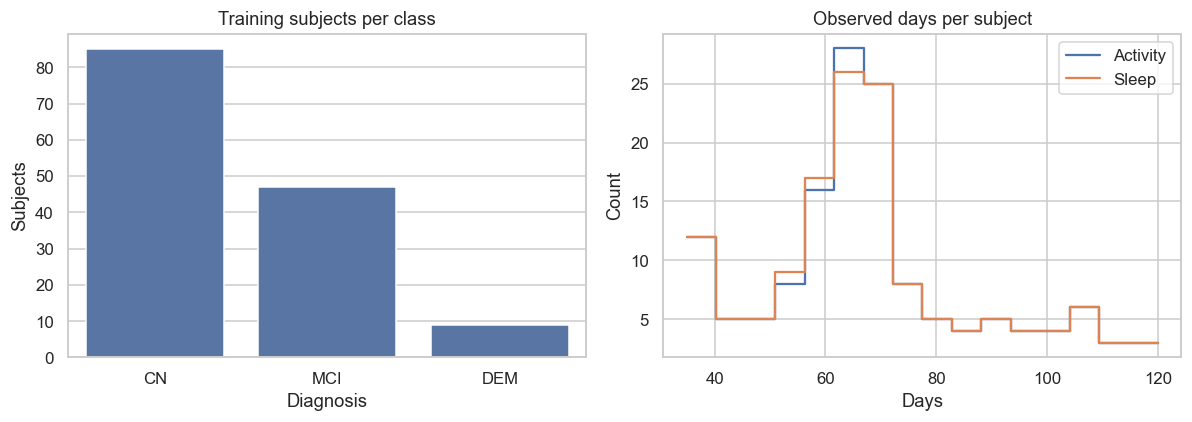

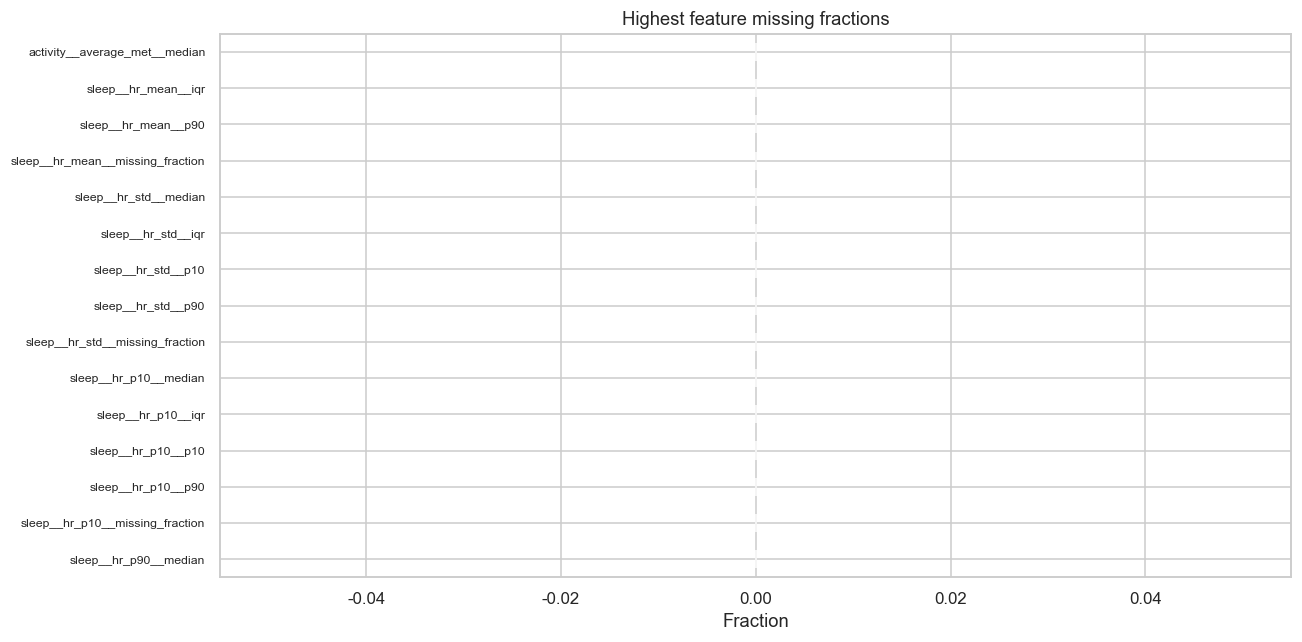

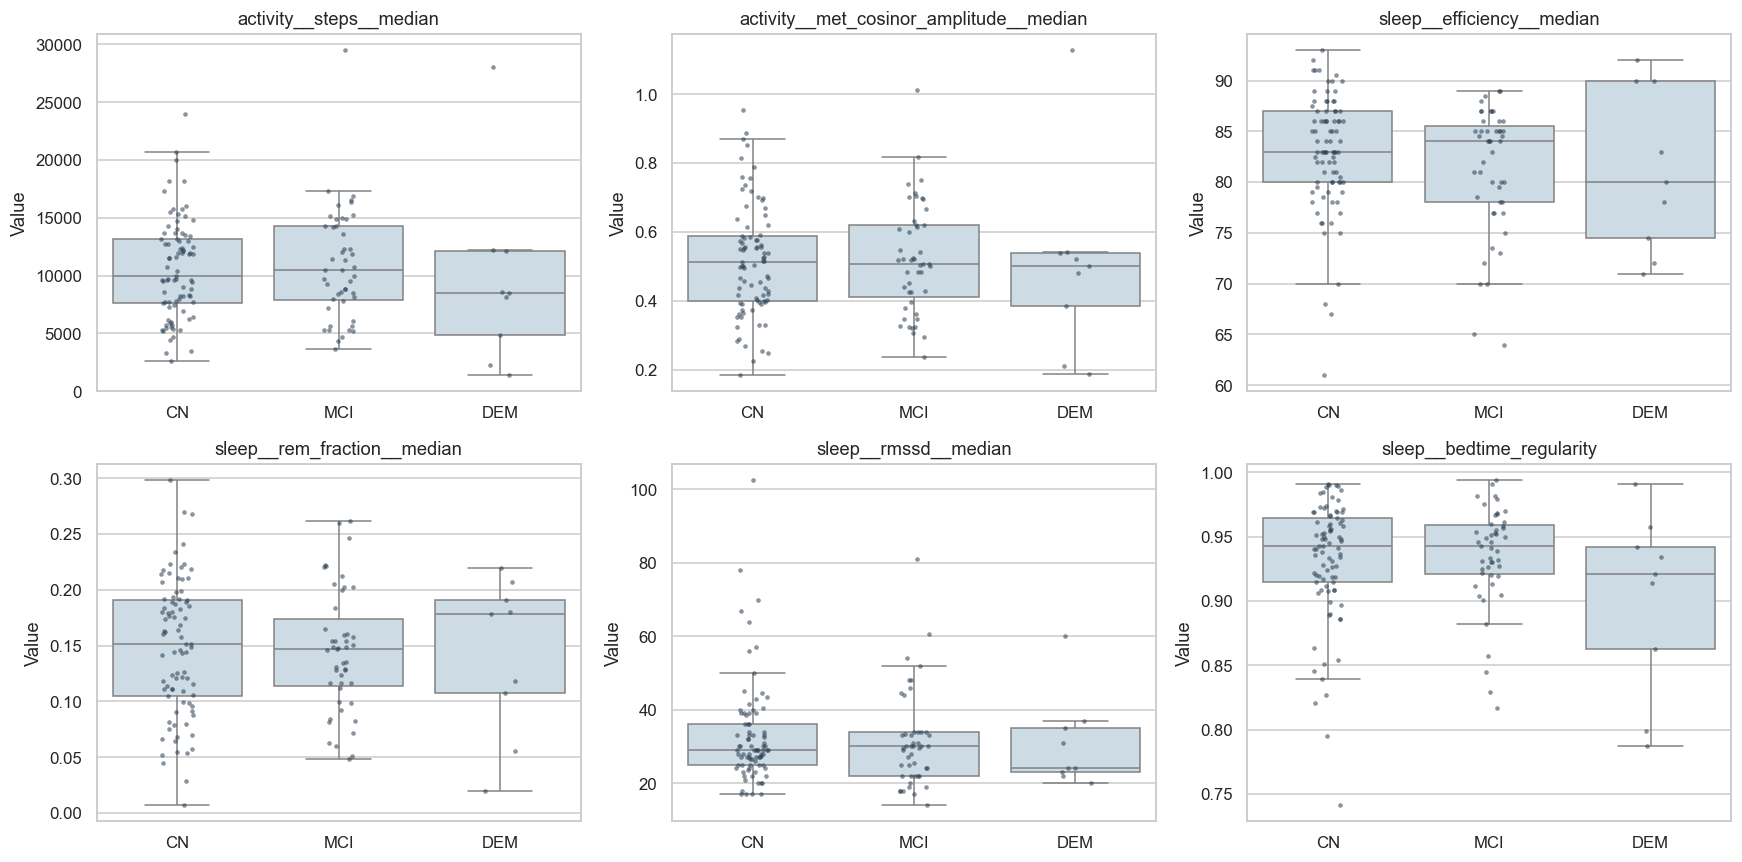

In [5]:
# EDA는 Training만 사용한다. 이 결과를 보고 특징을 바꾸면 새로운 개발 실험이다.
fig,axes=plt.subplots(1,2,figsize=(11,4))
sns.countplot(x=pd.Categorical(np.array(CLASS_NAMES)[y_train],categories=CLASS_NAMES),ax=axes[0])
axes[0].set(title='Training subjects per class',xlabel='Diagnosis',ylabel='Subjects')
for modality,frame in [('Activity',train_activity),('Sleep',train_sleep)]:
    sns.histplot(frame.groupby('subject').size(),bins=16,element='step',fill=False,label=modality,ax=axes[1])
axes[1].set(title='Observed days per subject',xlabel='Days'); axes[1].legend()
plt.tight_layout(); plt.show()
missing=X_train.isna().mean().sort_values(ascending=False).head(15)
fig,ax=plt.subplots(figsize=(12,6))
missing.iloc[::-1].plot.barh(ax=ax,color='#7194ad')
ax.set(title='Highest feature missing fractions',xlabel='Fraction')
ax.tick_params(axis='y',labelsize=8)
plt.tight_layout(); plt.show()

eda_features=['activity__steps__median','activity__met_cosinor_amplitude__median',
              'sleep__efficiency__median','sleep__rem_fraction__median',
              'sleep__rmssd__median','sleep__bedtime_regularity']
fig,axes=plt.subplots(2,3,figsize=(16,8))
for ax,col in zip(axes.flat,eda_features):
    if col not in X_train: continue
    eda=pd.DataFrame({'value':X_train[col].to_numpy(),'class':np.array(CLASS_NAMES)[y_train]})
    sns.boxplot(data=eda,x='class',y='value',order=CLASS_NAMES,showfliers=False,ax=ax,color='#c9dce8')
    sns.stripplot(data=eda,x='class',y='value',order=CLASS_NAMES,ax=ax,color='#283d51',alpha=.55,size=3)
    ax.set(title=col,xlabel='',ylabel='Value')
plt.tight_layout(); plt.show()


## 3. 단일 GroupKFold 성능 탐색

**중첩 CV는 사용하지 않는다.** 모든 후보는 동일한 5-fold GroupKFold를 사용한다. 클래스 계층화가 없는 GroupKFold이므로 학습 fold에 세 클래스가 모두 있는지 검사하고, 검증 fold에서 클래스가 빠져도 macro-F1은 CN/MCI/DEM 고정 3개 클래스로 계산한다. 일부 fold에 없는 클래스의 AUC는 정의하지 않는다. 좋은 점수가 나오는 분할을 고르는 seed 탐색은 하지 않는다.

1. 각 view에서 Optuna로 트리 깊이·반복 수·학습률·정규화·클래스 가중치·특징 수를 탐색한다. 학습 fold에서만 결측/상수 필터와 ANOVA 순위를 만들고, CatBoost는 원래 NaN을 받는다. 선택에는 pooled OOF macro-F1을 사용한다.
2. 선택된 설정을 고정하고 같은 분할에서 3개 seed를 평균해 안정성을 높인다.
3. 두 view의 raw logits 가중 평균과 작은 클래스별 logit 보정값을 OOF에서 선택한다. 확률은 최종 logits의 softmax이다. 가중치 0/1도 허용해 단일 view가 더 좋으면 단순 모델을 선택할 수 있다.
4. 그 설정 그대로 전체 Training으로 최종 모델을 학습한 뒤 Validation을 평가한다. Validation 라벨은 튜닝·보정·특징 선택에 사용하지 않는다.

**OOF는 해당 피험자를 직접 학습하지 않은 예측이지만, 같은 OOF 정답으로 하이퍼파라미터와 결합을 선택했으므로 성능이 낙관적일 수 있는 개발 점수다.** SHAP도 이 개발 과정에서 선택된 모델의 설명이다. 일반화 성능의 주 보고값은 아래의 보존된 Validation 결과다. 클래스 보정 및 가중 학습 뒤의 확률은 별도 검증된 임상 확률로 해석하지 않는다.


In [6]:
# This cell defines the modelling pipeline; it does not start training.
import warnings
from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd
import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.feature_selection import f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, log_loss, roc_auc_score,
)
from sklearn.model_selection import GroupKFold


CLASS_IDS = np.array([0, 1, 2], dtype=int)
CLASS_NAMES = ("CN", "MCI", "DEM")
VIEW_NAMES = ("all", "physiology")


def _resolve_training_inputs(X=None, y=None, groups=None, cfg=None):
    """One sample per subject; no official holdout is accessed by this function."""
    X = X_train if X is None else X
    y = y_train if y is None else y
    groups = groups_train if groups is None else groups
    cfg = dict(CFG if cfg is None else cfg)
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a DataFrame indexed by subject.")
    if not X.index.is_unique or not X.columns.is_unique:
        raise ValueError("Duplicate subjects or feature columns are not allowed.")
    if not all(isinstance(c, str) for c in X.columns):
        raise TypeError("Feature names must be strings.")
    bad_types = [c for c in X if not pd.api.types.is_numeric_dtype(X[c])]
    if bad_types:
        raise TypeError(f"Only numeric, engineered features are expected: {bad_types[:8]}")
    X = X.astype(float).replace([np.inf, -np.inf], np.nan).copy()
    if isinstance(y, pd.Series) and not y.index.equals(X.index):
        raise ValueError("y Series index/order must match X.index.")
    if isinstance(groups, pd.Series) and not groups.index.equals(X.index):
        raise ValueError("groups Series index/order must match X.index.")
    y_original = np.asarray(y)
    if y_original.ndim != 1 or pd.isna(y_original).any():
        raise ValueError("y must be a one-dimensional array without missing labels.")
    y = y_original.astype(int)
    if not np.array_equal(y_original, y) or set(np.unique(y)) != {0, 1, 2}:
        raise ValueError("Training labels must contain all of CN=0, MCI=1, DEM=2.")
    groups = np.asarray(groups)
    if groups.ndim != 1 or pd.isna(groups).any():
        raise ValueError("Subject groups must be one-dimensional and nonmissing.")
    groups = groups.astype(str)
    if not (len(X) == len(y) == len(groups)):
        raise ValueError("X, y and subject groups must have identical lengths.")
    if not np.array_equal(groups, X.index.astype(str).to_numpy()):
        raise ValueError("Groups must match the subject-index order.")
    if len(np.unique(groups)) != len(groups):
        raise ValueError("Aggregate repeated observations to one row per subject first.")
    if int(cfg.get("n_trials", 0)) < 1:
        raise ValueError("n_trials must be positive.")
    return X, y, groups, cfg


def _feature_fingerprint(X):
    import hashlib
    payload = pd.util.hash_pandas_object(X.astype(float), index=True).to_numpy().tobytes()
    return hashlib.sha256(payload).hexdigest()


def _softmax(raw):
    raw = np.asarray(raw, dtype=float)
    shifted = raw - np.max(raw, axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)


def classification_metrics(y, probabilities):
    """Macro-F1 always includes the three predefined classes, even if absent."""
    y = np.asarray(y, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    if probabilities.shape != (len(y), 3):
        raise ValueError("Expected a probability matrix with shape (n_subjects, 3).")
    pred = probabilities.argmax(axis=1)
    cm = confusion_matrix(y, pred, labels=CLASS_IDS)
    supports = cm.sum(axis=1)
    recalls = np.divide(np.diag(cm), supports, out=np.zeros(3), where=supports > 0)
    result = {
        "macro_f1": f1_score(y, pred, labels=CLASS_IDS, average="macro", zero_division=0),
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": float(recalls[supports > 0].mean()),
        "log_loss": log_loss(y, probabilities, labels=CLASS_IDS),
        "roc_auc_ovr_macro": np.nan,
    }
    if set(np.unique(y)) == {0, 1, 2}:
        result["roc_auc_ovr_macro"] = roc_auc_score(
            y, probabilities, labels=CLASS_IDS, multi_class="ovr", average="macro"
        )
    for class_id, name in enumerate(CLASS_NAMES):
        result[f"recall_{name}"] = float(recalls[class_id]) if supports[class_id] else np.nan
        result[f"n_{name}"] = int(supports[class_id])
    return result


def _group_splits(X, y, groups, n_splits, seed):
    """Literal sklearn GroupKFold; shuffled groups, never row-wise splitting."""
    if n_splits < 2 or len(np.unique(groups)) < n_splits:
        raise ValueError(f"Insufficient subject groups for {n_splits} folds.")
    splitter = GroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    splits, rows = [], []
    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), 1):
        if np.intersect1d(groups[train_idx], groups[test_idx]).size:
            raise RuntimeError("Subject leakage detected.")
        if set(np.unique(y[train_idx])) != {0, 1, 2}:
            raise ValueError(
                f"Fold {fold}: training partition misses a class. "
                "The dataset is too sparse for this GroupKFold configuration; "
                "revise the predeclared fold count before the experiment."
            )
        row = {"fold": fold, "train_subjects": len(train_idx), "validation_subjects": len(test_idx)}
        for class_id, name in enumerate(CLASS_NAMES):
            row[f"train_{name}"] = int(np.sum(y[train_idx] == class_id))
            row[f"validation_{name}"] = int(np.sum(y[test_idx] == class_id))
        if set(np.unique(y[test_idx])) != {0, 1, 2}:
            warnings.warn(
                f"Fold {fold} lacks a validation class. Macro-F1 retains "
                "labels=[0,1,2]; AUROC is undefined for that fold.", stacklevel=2,
            )
        splits.append((train_idx, test_idx))
        rows.append(row)
    return splits, pd.DataFrame(rows)


def _view_columns(X, view):
    if view not in VIEW_NAMES:
        raise ValueError(f"Unknown feature view: {view}")
    absent = X.columns.difference(FEATURE_META.index)
    if len(absent):
        raise ValueError(f"Feature metadata is missing: {absent[:8].tolist()}")
    if FEATURE_META.index.has_duplicates:
        raise ValueError("FEATURE_META must have a unique feature-name index.")
    meta = FEATURE_META.loc[X.columns]
    if "family" not in meta or meta["family"].isna().any():
        raise ValueError("Each feature requires a nonmissing family in FEATURE_META.")
    if view == "all":
        return X.columns.tolist()
    return meta.index[~meta["family"].isin(["quality", "vendor"])].tolist()


@dataclass
class FoldFeatureSelector:
    """Fit only on a training partition; imputation is used only for ranking."""

    top_k: Any = "all"
    min_observed_fraction: float = 0.10

    def fit(self, X, y):
        minimum = max(2, int(np.ceil(len(X) * self.min_observed_fraction)))
        usable = (X.notna().sum() >= minimum) & (X.nunique(dropna=True) > 1)
        self.eligible_columns_ = X.columns[usable].tolist()
        if not self.eligible_columns_:
            raise ValueError("No varying, sufficiently observed features in this training fold.")
        candidate = X.loc[:, self.eligible_columns_]
        self.imputer_ = SimpleImputer(strategy="median")
        ranked_data = self.imputer_.fit_transform(candidate)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            scores, _ = f_classif(ranked_data, y)
        scores = np.nan_to_num(scores, nan=-np.inf, posinf=np.finfo(float).max, neginf=-np.inf)
        self.ranking_ = pd.Series(scores, index=self.eligible_columns_).sort_values(
            ascending=False, kind="mergesort"
        )
        k = len(self.eligible_columns_) if self.top_k == "all" else min(int(self.top_k), len(candidate.columns))
        selected = set(self.ranking_.index[:k])
        # Preserve original order, giving consistent model/SHAP feature names.
        self.selected_columns_ = [c for c in self.eligible_columns_ if c in selected]
        return self

    def transform(self, X):
        missing = pd.Index(self.selected_columns_).difference(X.columns)
        if len(missing):
            raise ValueError(f"Required features are absent: {missing[:8].tolist()}")
        # Deliberately preserve NaN: CatBoost learns missing-value branches.
        return X.loc[:, self.selected_columns_].astype(float).replace([np.inf, -np.inf], np.nan)


In [7]:
def _trial_parameters(trial, cfg, seed):
    top_k = trial.suggest_categorical("top_k", [40, 80, 160, "all"])
    class_weight = trial.suggest_categorical("class_weight", ["None", "SqrtBalanced", "Balanced"])
    params = {
        "loss_function": "MultiClass",
        "iterations": trial.suggest_categorical("iterations", [300, 500, 750, 1000]),
        "depth": trial.suggest_int("depth", 3, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.015, 0.12, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 3.0, 80.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.05, 4.0, log=True),
        "bootstrap_type": "Bayesian",
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        "random_seed": int(seed),
        "thread_count": int(cfg["thread_count"]),
        "task_type": cfg.get("task_type", "CPU"),
        "allow_writing_files": False,
        "verbose": False,
        "nan_mode": "Min",
    }
    if params["task_type"] == "CPU":
        params["boosting_type"] = "Ordered"
        params["rsm"] = trial.suggest_float("rsm", 0.70, 1.0)
    else:
        params["boosting_type"] = "Plain"
        params["devices"] = str(cfg.get("devices", "0"))
    if class_weight != "None":
        params["auto_class_weights"] = class_weight
    return params, top_k


def _fit_member(X, y, view, params, top_k):
    candidate_columns = _view_columns(X, view)
    if not candidate_columns:
        raise ValueError(f"No input features exist for the {view} view.")
    selector = FoldFeatureSelector(top_k=top_k).fit(X.loc[:, candidate_columns], y)
    model = CatBoostClassifier(**params)
    # No eval_set/early stopping: validation labels never influence model fitting.
    model.fit(selector.transform(X), y)
    if not np.array_equal(np.asarray(model.classes_, dtype=int), CLASS_IDS):
        raise RuntimeError("Unexpected CatBoost class order.")
    return {"view": view, "selector": selector, "model": model, "params": dict(params), "top_k": top_k}


def _member_raw(member, X):
    raw = np.asarray(
        member["model"].predict(member["selector"].transform(X), prediction_type="RawFormulaVal"),
        dtype=float,
    )
    if raw.shape != (len(X), 3):
        raise RuntimeError(f"Unexpected multiclass logit shape: {raw.shape}")
    return raw


def _tune_view(X, y, view, cv_splits, cfg, seed):
    # Reuse the same subject folds for every trial. Official holdout is untouched.
    cache = {}
    sampler = optuna.samplers.TPESampler(seed=int(seed), n_startup_trials=min(8, int(cfg["n_trials"])))
    study = optuna.create_study(direction="maximize", sampler=sampler, study_name=f"{view}_{seed}")

    def objective(trial):
        params, top_k = _trial_parameters(trial, cfg, seed)
        raw_oof = np.full((len(X), 3), np.nan)
        selected_counts = []
        for train_idx, validation_idx in cv_splits:
            member = _fit_member(X.iloc[train_idx], y[train_idx], view, params, top_k)
            raw_oof[validation_idx] = _member_raw(member, X.iloc[validation_idx])
            selected_counts.append(len(member["selector"].selected_columns_))
        if not np.isfinite(raw_oof).all():
            raise RuntimeError("Incomplete/nonfinite grouped out-of-fold predictions.")
        metric = classification_metrics(y, _softmax(raw_oof))
        trial.set_user_attr("macro_f1", float(metric["macro_f1"]))
        trial.set_user_attr("log_loss", float(metric["log_loss"]))
        trial.set_user_attr("mean_selected_features", float(np.mean(selected_counts)))
        cache[trial.number] = {"params": params, "top_k": top_k, "metrics": metric}
        return float(metric["macro_f1"])

    # Sequential trials avoid oversubscribing CPU and RAM.
    def report_progress(study, trial):
        if (trial.number + 1) % 5 == 0 or trial.number + 1 == int(cfg["n_trials"]):
            print(f"  {view}: {trial.number + 1}/{cfg['n_trials']} trials, best development F1={study.best_value:.4f}", flush=True)
    study.optimize(objective, n_trials=int(cfg["n_trials"]), n_jobs=1,
                   show_progress_bar=False, callbacks=[report_progress])
    chosen_number = max(
        cache,
        key=lambda number: (cache[number]["metrics"]["macro_f1"], -cache[number]["metrics"]["log_loss"], -number),
    )
    study.set_user_attr("selected_trial_number", int(chosen_number))
    chosen = cache[chosen_number]
    chosen["study"] = study
    chosen["selected_trial_number"] = chosen_number
    return chosen


def _choose_blend_and_offsets(y, all_raw, physiology_raw):
    """OOF tuning only: the resulting CV score is a selection score."""
    candidates = []
    for weight in (0.0, 0.25, 0.50, 0.75, 1.0):
        for mci_offset in (-0.2, 0.0, 0.2):
            for dem_offset in (-0.2, 0.0, 0.2):
                offset = np.array([0.0, mci_offset, dem_offset])
                offset -= offset.mean()  # Identifiable sum-zero logit adjustment.
                raw = weight * all_raw + (1.0 - weight) * physiology_raw + offset
                metrics = classification_metrics(y, _softmax(raw))
                candidates.append({
                    "weight_all": weight, "offset_CN": float(offset[0]),
                    "offset_MCI": float(offset[1]), "offset_DEM": float(offset[2]),
                    "offset_norm": float(np.linalg.norm(offset)), **metrics,
                })
    best = max(candidates, key=lambda row: (
        row["macro_f1"], -row["log_loss"], -row["offset_norm"], -row["weight_all"]
    ))
    offset = np.array([best[f"offset_{name}"] for name in CLASS_NAMES], dtype=float)
    table = pd.DataFrame(candidates)
    table["selected"] = (
        np.isclose(table["weight_all"], best["weight_all"])
        & np.isclose(table["offset_MCI"], best["offset_MCI"])
        & np.isclose(table["offset_DEM"], best["offset_DEM"])
    )
    return float(best["weight_all"]), offset, table


def _fit_seed_members(X, y, view, chosen, cfg):
    members = []
    for seed in cfg["seeds"]:
        params = dict(chosen["params"])
        params["random_seed"] = int(seed)
        members.append(_fit_member(X, y, view, params, chosen["top_k"]))
    return members


def _view_raw(members, X):
    return np.mean([_member_raw(member, X) for member in members], axis=0)


def _make_bundle(X, members, cfg, weight=0.5, offsets=None):
    return {
        "members": members, "weight_all": float(weight),
        "class_offsets": np.zeros(3) if offsets is None else np.asarray(offsets, dtype=float).copy(),
        "feature_names": X.columns.tolist(), "class_names": list(CLASS_NAMES),
        "class_ids": CLASS_IDS.copy(), "training_subjects": X.index.astype(str).tolist(),
        "cfg": dict(cfg),
    }


def predict_bundle(bundle, X, raw=False):
    """Return (n, 3) CN/MCI/DEM probabilities, or adjusted logits if raw=True."""
    if len(X) == 0:
        return np.empty((0, 3), dtype=float)
    weight = bundle["weight_all"]
    scores = np.broadcast_to(bundle["class_offsets"], (len(X), 3)).copy()
    for view, view_weight in (("all", weight), ("physiology", 1.0 - weight)):
        if view_weight:
            scores += view_weight * _view_raw(bundle["members"][view], X)
    return scores if raw else _softmax(scores)


def explain_bundle(bundle, X):
    """Exact weighted CatBoost SHAP for adjusted class logits, not probabilities.

    Returns values (n, 3, p), base_values (n, 3), raw_predictions (n, 3),
    feature_names, data (DataFrame), and additivity_max_abs_error. Unselected
    features have zero SHAP. Seed means and view blending are linear, so native
    raw-logit SHAP can be averaged exactly. Class offsets enter base_values.
    Explain subjects excluded from the individual bundle's model fitting only.
    These CV explanations still belong to a CV-selected model, not an unbiased
    evaluation cohort; use the untouched official holdout for final assessment.
    """
    if len(X) == 0:
        raise ValueError("SHAP requires at least one subject.")
    overlap = set(X.index.astype(str)) & set(bundle["training_subjects"])
    if overlap:
        raise ValueError("SHAP subjects must be excluded from this bundle's model fitting.")
    names = bundle["feature_names"]
    feature_position = {name: position for position, name in enumerate(names)}
    values = np.zeros((len(X), 3, len(names)), dtype=float)
    base_values = np.broadcast_to(bundle["class_offsets"], (len(X), 3)).copy()
    weight = bundle["weight_all"]
    for view, view_weight in (("all", weight), ("physiology", 1.0 - weight)):
        if not view_weight:
            continue
        members = bundle["members"][view]
        member_weight = view_weight / len(members)
        for member in members:
            selected_X = member["selector"].transform(X)
            shap_values = np.asarray(
                member["model"].get_feature_importance(
                    Pool(selected_X), type="ShapValues", thread_count=int(bundle["cfg"]["thread_count"])
                ), dtype=float,
            )
            expected_shape = (len(X), 3, selected_X.shape[1] + 1)
            if shap_values.shape != expected_shape:
                raise RuntimeError(f"Unexpected SHAP shape: {shap_values.shape}; expected {expected_shape}")
            for local_position, name in enumerate(selected_X.columns):
                values[:, :, feature_position[name]] += member_weight * shap_values[:, :, local_position]
            base_values += member_weight * shap_values[:, :, -1]
    raw_prediction = predict_bundle(bundle, X, raw=True)
    residual = values.sum(axis=2) + base_values - raw_prediction
    max_error = float(np.abs(residual).max())
    if not np.allclose(values.sum(axis=2) + base_values, raw_prediction, rtol=1e-5, atol=1e-5):
        raise RuntimeError(f"Ensemble SHAP additivity failed: max residual={max_error:.3g}")
    return {
        "values": values, "base_values": base_values, "raw_predictions": raw_prediction,
        "feature_names": names, "data": X.reindex(columns=names).copy(),
        "additivity_max_abs_error": max_error,
    }


def _tuning_rows(tuned):
    rows = []
    for view, result in tuned.items():
        for trial in result["study"].trials:
            rows.append({
                "view": view, "trial": trial.number,
                "selected": trial.number == result["selected_trial_number"],
                "state": str(trial.state), "objective_macro_f1": trial.value,
                **trial.user_attrs, **trial.params,
            })
    return rows


In [8]:
def tune_groupcv(X=None, y=None, groups=None, cfg=None):
    """Tune once with subject GroupKFold, then build three-seed OOF ensembles.

    Optuna, feature count, class weights, view blend and class offsets all use
    the same GroupKFold predictions. Reported OOF performance is therefore an
    optimistic model-selection score. Only the untouched official holdout can
    assess the selected pipeline independently. No holdout input is read here.
    """
    X, y, groups, cfg = _resolve_training_inputs(X, y, groups, cfg)
    seeds = [int(seed) for seed in cfg["seeds"]]
    if not seeds or len(set(seeds)) != len(seeds):
        raise ValueError("Provide distinct nonempty random seeds.")
    cfg["seeds"] = seeds
    cv_splits, split_table = _group_splits(
        X, y, groups, int(cfg["n_splits"]), int(cfg.get("seed", seeds[0]))
    )
    print(split_table.to_string(index=False), flush=True)
    tuned = {}
    for view_index, view in enumerate(VIEW_NAMES):
        print(f"Tuning {view}: {cfg['n_trials']} trials × {cfg['n_splits']} subject folds", flush=True)
        tuned[view] = _tune_view(X, y, view, cv_splits, cfg, seeds[0] + 101 * view_index)
    raw_by_view = {view: np.full((len(X), 3), np.nan) for view in VIEW_NAMES}
    prior_oof = np.full((len(X), 3), np.nan)
    fold_bundles = []
    for fold, (train_idx, test_idx) in enumerate(cv_splits, 1):
        print(f"Seed ensemble fold {fold}/{cfg['n_splits']}: train={len(train_idx)}, validation={len(test_idx)}", flush=True)
        members = {
            view: _fit_seed_members(X.iloc[train_idx], y[train_idx], view, tuned[view], cfg)
            for view in VIEW_NAMES
        }
        bundle = _make_bundle(X.iloc[train_idx], members, cfg)
        for view in VIEW_NAMES:
            raw_by_view[view][test_idx] = _view_raw(members[view], X.iloc[test_idx])
        # Equivalent to DummyClassifier(strategy='prior'), trained per fold.
        prior_oof[test_idx] = np.bincount(y[train_idx], minlength=3).astype(float) / len(train_idx)
        fold_bundles.append({"fold": fold, "train_idx": train_idx, "test_idx": test_idx, "bundle": bundle})
    if any(not np.isfinite(raw).all() for raw in raw_by_view.values()):
        raise RuntimeError("Incomplete grouped OOF predictions.")
    weight, offsets, selection_table = _choose_blend_and_offsets(
        y, raw_by_view["all"], raw_by_view["physiology"]
    )
    oof = _softmax(weight * raw_by_view["all"] + (1.0 - weight) * raw_by_view["physiology"] + offsets)
    by_view_oof = {view: _softmax(raw_by_view[view]) for view in VIEW_NAMES}
    by_view_oof["prior"] = prior_oof
    fold_rows = []
    for entry in fold_bundles:
        bundle, test_idx = entry["bundle"], entry["test_idx"]
        bundle["weight_all"] = weight
        bundle["class_offsets"] = offsets.copy()
        for model_name, probabilities in {"selected_ensemble": oof, **by_view_oof}.items():
            fold_rows.append({
                "fold": entry["fold"], "model": model_name,
                "train_subjects": len(entry["train_idx"]), "validation_subjects": len(test_idx),
                "weight_all": weight,
                "n_features_all": len(bundle["members"]["all"][0]["selector"].selected_columns_),
                "n_features_physiology": len(bundle["members"]["physiology"][0]["selector"].selected_columns_),
                **classification_metrics(y[test_idx], probabilities[test_idx]),
            })
    pooled_table = pd.DataFrame([
        {"model": name, **classification_metrics(y, probabilities)}
        for name, probabilities in {"selected_ensemble": oof, **by_view_oof}.items()
    ])
    best_params = {
        view: {"params": dict(tuned[view]["params"]), "top_k": tuned[view]["top_k"],
               "selected_trial_number": tuned[view]["selected_trial_number"]}
        for view in VIEW_NAMES
    }
    return {
        "oof": oof, "by_view_oof": by_view_oof, "raw_by_view": raw_by_view,
        "fold_table": pd.DataFrame(fold_rows), "pooled_table": pooled_table,
        "split_table": split_table, "fold_bundles": fold_bundles,
        "studies": {view: tuned[view]["study"] for view in VIEW_NAMES},
        "selection_table": selection_table, "best_params": best_params,
        "weight_all": weight, "class_offsets": offsets,
        "tuning_history": pd.DataFrame(_tuning_rows(tuned)),
        "y": y.copy(), "groups": groups.copy(), "subject_index": X.index.copy(),
        "feature_names": X.columns.tolist(), "feature_fingerprint": _feature_fingerprint(X), "cfg": dict(cfg),
    }


def fit_selected_training(result, X=None, y=None, groups=None, cfg=None):
    """Fit selected parameters/seeds on all training subjects, without retuning.

    No holdout data is accessed here. Returns the final model bundle directly.
    """
    cfg = result["cfg"] if cfg is None else cfg
    X, y, groups, cfg = _resolve_training_inputs(X, y, groups, cfg)
    if not X.index.equals(result["subject_index"]) or X.columns.tolist() != result["feature_names"]:
        raise ValueError("Training subject order/feature schema changed after grouped tuning.")
    if _feature_fingerprint(X) != result["feature_fingerprint"]:
        raise ValueError("Training feature values changed after tuning.")
    if not np.array_equal(y, result["y"]) or not np.array_equal(groups, result["groups"]):
        raise ValueError("Training labels/groups changed after grouped tuning.")
    if list(cfg["seeds"]) != list(result["cfg"]["seeds"]):
        raise ValueError("Keep the selected seed ensemble unchanged for final fitting.")
    members = {
        view: _fit_seed_members(X, y, view, result["best_params"][view], cfg)
        for view in VIEW_NAMES
    }
    bundle = _make_bundle(X, members, cfg, result["weight_all"], result["class_offsets"])
    bundle["best_params"] = result["best_params"]
    bundle["selection_table"] = result["selection_table"].copy()
    return bundle


In [9]:
# 실제 실행은 이 셀부터 모델을 학습합니다. 작성 과정에서는 실행하지 않았습니다.
cv_result=tune_groupcv(X_train,y_train,groups_train)
display(cv_result['split_table'])
display(cv_result['fold_table'])
display(cv_result['pooled_table'])
display(cv_result['selection_table'].sort_values(['selected','macro_f1','log_loss'],ascending=[False,False,True]).head(10))
display(cv_result['tuning_history'].sort_values(['view','trial']))


 fold  train_subjects  validation_subjects  train_CN  validation_CN  train_MCI  validation_MCI  train_DEM  validation_DEM
    1             112                   29        66             19         40               7          6               3
    2             113                   28        68             17         37              10          8               1
    3             113                   28        67             18         38               9          8               1
    4             113                   28        72             13         35              12          6               3
    5             113                   28        67             18         38               9          8               1
Tuning all: 40 trials × 5 subject folds
  all: 5/40 trials, best development F1=0.4111
  all: 10/40 trials, best development F1=0.4111
  all: 15/40 trials, best development F1=0.4111
  all: 20/40 trials, best development F1=0.4111
  all: 25/40 trials, best development

[W 2026-09-22 16:32:58,552] Trial 9 failed with parameters: {'top_k': 'all', 'class_weight': 'Balanced', 'iterations': 1000, 'depth': 3, 'learning_rate': 0.017003015274699416, 'l2_leaf_reg': 20.604513148539734, 'random_strength': 0.07539969142068853, 'bagging_temperature': 1.8968836903552044, 'rsm': 0.7139660090067168} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/Users/pig30nidae/Pig30nidaE/Project/3-class/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/hf/6g75lk2j3_n652n7198vpl1w0000gn/T/ipykernel_15255/1719394878.py", line 65, in objective
    member = _fit_member(X.iloc[train_idx], y[train_idx], view, params, top_k)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/hf/6g75lk2j3_n652n7198vpl1w0000gn/T/ipykernel_15255/1719394878.py", line 38, in _fit_member

KeyboardInterrupt: 

## 4. 개발 OOF 결과와 시각화

아래 점수는 단일 GroupKFold에서 튜닝에 사용한 **개발 OOF**다. 각 피험자의 모든 일별 기록은 하나의 그룹에 속한다. 비교 표의 view별 결과를 보고 다시 최종 모델을 고르지 않으며, 이미 정의한 OOF 결합 선택 규칙을 그대로 따른다. prior 기준선은 fold의 학습 클래스 비율만으로 예측한다.


In [ ]:
def plot_evaluation(y,probs,title):
    y=np.asarray(y); pred=probs.argmax(axis=1)
    fig,axes=plt.subplots(2,2,figsize=(12,10))
    counts=confusion_matrix(y,pred,labels=[0,1,2])
    normalized=np.divide(counts,counts.sum(axis=1,keepdims=True),
                         out=np.zeros_like(counts,dtype=float),where=counts.sum(axis=1,keepdims=True)>0)
    sns.heatmap(counts,annot=True,fmt='d',cmap='Blues',xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,ax=axes[0,0],cbar=False)
    sns.heatmap(normalized,annot=True,fmt='.2f',vmin=0,vmax=1,cmap='Blues',
                xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=axes[0,1])
    axes[0,0].set(title='Confusion matrix: subjects',xlabel='Predicted',ylabel='True')
    axes[0,1].set(title='Recall-normalized confusion matrix',xlabel='Predicted',ylabel='True')
    for k,name in enumerate(CLASS_NAMES):
        binary=(y==k).astype(int)
        if len(np.unique(binary))<2: continue
        fpr,tpr,_=roc_curve(binary,probs[:,k])
        auc=roc_auc_score(binary,probs[:,k])
        axes[1,0].plot(fpr,tpr,label=f'{name}: AUC={auc:.3f}')
        precision,recall,_=precision_recall_curve(binary,probs[:,k])
        ap=average_precision_score(binary,probs[:,k])
        axes[1,1].plot(recall,precision,label=f'{name}: AP={ap:.3f}, n={binary.sum()}')
    axes[1,0].plot([0,1],[0,1],'k--',alpha=.4)
    axes[1,0].set(title='One-vs-rest ROC',xlabel='False positive rate',ylabel='True positive rate')
    axes[1,1].set(title='One-vs-rest precision-recall',xlabel='Recall',ylabel='Precision')
    for ax in axes[1]: ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1.02)
    fig.suptitle(title,fontsize=16); plt.tight_layout(); plt.show()
    display(pd.DataFrame(classification_report(y,pred,labels=[0,1,2],target_names=CLASS_NAMES,
                                              zero_division=0,output_dict=True)).T)

plot_evaluation(y_train,cv_result['oof'],'Development OOF — used for model selection')
# view / 선택 결합 / prior 비교. 모델을 고르는 데 이 표를 다시 사용하지 않는다.
comparison={name:classification_metrics(y_train,p) for name,p in cv_result['by_view_oof'].items()}
comparison['selected']=classification_metrics(y_train,cv_result['oof'])
comparison=pd.DataFrame(comparison).T
display(comparison)
comparison[['macro_f1','balanced_accuracy','accuracy']].plot.bar(figsize=(9,4),ylim=(0,1),rot=0)
plt.title('Development OOF comparison'); plt.tight_layout(); plt.show()


## 5. 피험자를 학습에서 제외한 SHAP 분석

각 피험자를 검증에 두었던 fold 모델들로 SHAP을 계산한다. 모든 구성모델이 CatBoost의 **raw logit**을 설명하므로, seed 평균과 view 가중치를 동일하게 적용해 앙상블 설명을 합칠 수 있다. 클래스 logit 보정은 baseline에 더한다. 각 사례에서 baseline + SHAP 합 = 최종 raw logits인지 검사한다. **softmax 후 확률에 대한 SHAP은 아니다.**

global importance와 CN/MCI/DEM별 중요도, DEM beeswarm, 사례별 waterfall, fold별 중요도 변화, 활동/수면/결합 특징군의 permutation 중요도를 함께 본다. 상관된 특징끼리는 기여가 나뉠 수 있고 permutation으로 비현실적인 조합이 생길 수 있다. 중요도는 원인이나 진단 기준을 증명하지 않는다. 튜닝에 사용된 개발 데이터의 설명이므로 확증적 바이오마커 발견으로 해석하지 않는다.


In [ ]:
rng=np.random.default_rng(CFG['seed'])
chosen=np.sort(rng.choice(len(X_train),size=min(CFG['shap_max_subjects'],len(X_train)),replace=False))
shap_values=np.full((len(X_train),3,X_train.shape[1]),np.nan,dtype=float)
shap_base=np.full((len(X_train),3),np.nan,dtype=float)
shap_fold=np.full(len(X_train),-1,dtype=int)
fold_importances=[]
for record in cv_result['fold_bundles']:
    idx=np.intersect1d(record['test_idx'],chosen)
    if not len(idx): continue
    explained=explain_bundle(record['bundle'],X_train.iloc[idx])
    shap_values[idx]=explained['values']
    shap_base[idx]=explained['base_values']
    shap_fold[idx]=record['fold']
    fold_importances.append(pd.Series(np.abs(explained['values']).mean(axis=(0,1)),
                                     index=X_train.columns,name=f"fold_{record['fold']}"))
    print('fold',record['fold'],'| explained:',len(idx),'| additivity error:',
          round(explained['additivity_max_abs_error'],9))
assert np.isfinite(shap_values[chosen]).all()
S=shap_values[chosen]; SX=X_train.iloc[chosen]
importance=pd.DataFrame({'mean_abs_shap':np.abs(S).mean(axis=(0,1))},index=X_train.columns)
for k,name in enumerate(CLASS_NAMES): importance[f'{name}_mean_abs_shap']=np.abs(S[:,k,:]).mean(axis=0)
stability=pd.concat(fold_importances,axis=1)
importance['nonzero_fold_fraction']=(stability>1e-10).mean(axis=1)
importance['fold_importance_std']=stability.std(axis=1)
importance=importance.join(FEATURE_META).sort_values('mean_abs_shap',ascending=False)
display(importance.head(30))
top=importance.head(20).index
fig,axes=plt.subplots(1,2,figsize=(17,8))
importance.loc[top,'mean_abs_shap'].iloc[::-1].plot.barh(ax=axes[0],color='#247b91')
axes[0].tick_params(axis='y',labelsize=8)
axes[0].set(title='Global |SHAP| — held-out subjects',xlabel='Mean absolute raw-logit contribution')
sns.heatmap(importance.loc[top,[f'{c}_mean_abs_shap' for c in CLASS_NAMES]],cmap='YlGnBu',ax=axes[1])
axes[1].set(title='Class-specific |SHAP|',xlabel='Class')
axes[1].tick_params(axis='y',labelsize=8)
plt.tight_layout(); plt.show()

# 글로벌 합계는 특징 수가 많은 그룹에 유리하므로 평균 중요도도 같이 표시.
group_importance=importance.groupby(['modality','family'])['mean_abs_shap'].agg(['sum','mean','count'])
display(group_importance.sort_values('sum',ascending=False))
fig,ax=plt.subplots(figsize=(10,7))
sns.heatmap(stability.loc[top],cmap='YlOrBr',ax=ax)
ax.set(title='Importance stability across validation folds',xlabel='Fold'); plt.tight_layout(); plt.show()

explanation=shap.Explanation(values=S[:,2,:],base_values=shap_base[chosen,2],
                              data=SX.to_numpy(),feature_names=list(SX.columns))
shap.plots.beeswarm(explanation,max_display=20,show=False)
plt.title('DEM raw-logit SHAP — held-out subjects'); plt.show()
# 재현 가능한 사례: 선택 샘플 중 첫 피험자. 원래 EMAIL은 출력하지 않는다.
local_index=0
shap.plots.waterfall(explanation[local_index],max_display=15,show=False)
plt.title('One held-out subject: DEM raw-logit explanation'); plt.show()

for name,row in importance.head(10).iterrows():
    print(f"{name}\n  {row['description']} | {row['modality']}/{row['family']} | "
          f"mean|SHAP|={row['mean_abs_shap']:.5f} | nonzero folds={row['nonzero_fold_fraction']:.0%}")


In [ ]:
# 구성요소가 아니라, 선택된 전체 앙상블의 modality 단위 permutation 중요도.
# 각 검증 fold 안에서 해당 modality의 모든 열을 같은 permutation으로 이동한다.
# 재학습 제거실험(ablation)이 아니며 correlated-group 중요도의 탐색적 지표다.
base_f1=f1_score(y_train,cv_result['oof'].argmax(axis=1),labels=[0,1,2],average='macro',zero_division=0)
permutation_rows=[]
for modality in ['activity','sleep','coupling']:
    columns=FEATURE_META.index[FEATURE_META['modality']==modality].tolist()
    if not columns: continue
    for repeat in range(CFG['permutation_repeats']):
        prng=np.random.default_rng(CFG['seed']+1000+repeat)
        changed=np.full_like(cv_result['oof'],np.nan)
        for record in cv_result['fold_bundles']:
            idx=record['test_idx']; xp=X_train.iloc[idx].copy()
            order=prng.permutation(len(xp))
            xp.loc[:,columns]=xp.iloc[order][columns].to_numpy()
            changed[idx]=predict_bundle(record['bundle'],xp)
        score=f1_score(y_train,changed.argmax(axis=1),labels=[0,1,2],average='macro',zero_division=0)
        permutation_rows.append({'modality':modality,'repeat':repeat,'macro_f1_drop':base_f1-score})
permutation_table=pd.DataFrame(permutation_rows)
display(permutation_table.groupby('modality')['macro_f1_drop'].agg(['mean','std']))
sns.boxplot(data=permutation_table,x='modality',y='macro_f1_drop',color='#bdd2df')
plt.axhline(0,color='k',linestyle='--'); plt.title('Development OOF grouped permutation importance')
plt.tight_layout(); plt.show()


## 6. 최종 학습과 보존된 Validation 평가

GroupKFold 개발 단계에서 선택한 특징 선택 규칙·모델 설정·seed·결합 가중치·클래스 보정을 고정한다. 최종 학습은 Training 전체만 사용한다. **이 결과를 본 뒤 모델을 바꿔 같은 Validation에서 다시 고르면 더 이상 최종 보존 검증이 아니다.**

신뢰구간은 클래스별 피험자를 복원추출하는 stratified bootstrap의 2.5–97.5 분위수다. 이 표본에서 클래스 수를 고정한 조건부 구간이며, 새 학습 표본이나 튜닝 자체의 불확실성을 포함하지 않는다. Validation DEM 3명에서는 한 명 차이가 recall 33.3%p 차이를 만든다.


In [ ]:
final_bundle=fit_selected_training(cv_result)

def subject_bootstrap_intervals(y,probabilities,n_boot=2000,seed=2026):
    rng=np.random.default_rng(seed)
    groups=[np.flatnonzero(y==k) for k in range(3)]
    metric_names=['macro_f1','accuracy','balanced_accuracy','recall_DEM','roc_auc_ovr_macro']
    collected=[]
    for _ in range(n_boot):
        idx=np.concatenate([rng.choice(g,size=len(g),replace=True) for g in groups if len(g)])
        score=classification_metrics(y[idx],probabilities[idx])
        collected.append([score[k] for k in metric_names])
    samples=pd.DataFrame(collected,columns=metric_names)
    actual=classification_metrics(y,probabilities)
    return pd.DataFrame({'estimate':pd.Series({k:actual[k] for k in metric_names}),
                         'lower_95':samples.quantile(.025),'upper_95':samples.quantile(.975)})

holdout_metrics=None
if len(X_holdout):
    holdout_probabilities=predict_bundle(final_bundle,X_holdout)
    holdout_metrics=classification_metrics(y_holdout,holdout_probabilities)
    display(pd.Series(holdout_metrics,name='Untouched official Validation'))
    plot_evaluation(y_holdout,holdout_probabilities,'Official Validation — subject-disjoint final evaluation')
    holdout_ci=subject_bootstrap_intervals(y_holdout,holdout_probabilities,
                        n_boot=CFG['bootstrap_repeats'],seed=CFG['seed'])
    display(holdout_ci)
    holdout_predictions=pd.DataFrame(holdout_probabilities,columns=[f'p_{x}' for x in CLASS_NAMES])
    holdout_predictions.insert(0,'subject_alias',[f'V{i+1:03d}' for i in range(len(X_holdout))])
    holdout_predictions['true']=np.array(CLASS_NAMES)[y_holdout]
    holdout_predictions['predicted']=np.array(CLASS_NAMES)[holdout_probabilities.argmax(axis=1)]
    display(holdout_predictions)
    # 확정된 모델을 처음 보는 holdout 피험자에 적용한 feature 설명. 모델 수정에 쓰지 않는다.
    holdout_explanation=explain_bundle(final_bundle,X_holdout)
    holdout_importance=pd.Series(np.abs(holdout_explanation['values']).mean(axis=(0,1)),
                                 index=X_train.columns,name='holdout_mean_abs_shap').sort_values(ascending=False)
    display(holdout_importance.head(20).to_frame().join(FEATURE_META))
    holdout_importance.head(20).iloc[::-1].plot.barh(figsize=(10,7),color='#276b64')
    plt.xlabel('Mean |SHAP|, raw logits'); plt.title('Official Validation feature importance')
    plt.tight_layout(); plt.show()
else:
    print('피험자가 겹치지 않는 Validation이 없어 최종 일반화 성능을 보고할 수 없습니다.')


## 7. 새 피험자 추론과 결과 해석

새 데이터도 동일한 스키마·시간대·관측기간·최소 관측일 규칙을 사용한다. 아래 함수는 학습을 다시 하지 않고 원천 활동/수면 CSV를 받아 예측한다. 피험자 ID는 집계·중복검사에만 쓰이고 입력 열에 들어가지 않는다. 결과는 메모리에 유지하며 추가 파일은 자동 생성하지 않는다.

실행 후 보고할 항목:

1. 대상자 제외 사유, 클래스별 인원, 실제 fold별 클래스 구성과 결측/중복 처리 결과.
2. **Validation macro-F1 및 클래스별 recall**, Accuracy, PR-AUC/ROC-AUC, bootstrap 구간. 개발 OOF는 별도 표기.
3. SHAP 상위 특징의 물리적 의미, 클래스별 기여 방향, fold별 중요도 변화, quality/vendor 특징의 영향.
4. SHAP global rank가 높아도 인과관계는 아니다. 관측량이나 비착용이 높게 나오면 질환 신호 외의 수집 방식 영향을 검토한다. physiology view도 간접적인 품질 영향까지 제거했다고 보장하지 않는다.
5. 진단 시점/약물/동반질환/인구통계/모집기관 정보는 제공 CSV의 허용 입력에 없으므로 교란을 조정하지 않았다. 이 모델은 관측된 라벨의 연구용 분류기이며 발병 시점·진행 위험을 추정하지 않는다.


In [ ]:
def predict_new_subjects(activity_csv,sleep_csv,bundle=None):
    bundle=final_bundle if bundle is None else bundle
    activity=load_daily(Path(activity_csv),'activity','Inference')
    sleep=load_daily(Path(sleep_csv),'sleep','Inference')
    features,_,_,days=build_subjects(activity,sleep)
    features=features.reindex(columns=bundle['feature_names'])
    if CFG['observation_days'] != bundle['cfg']['observation_days'] or CFG['min_days'] != bundle['cfg']['min_days']:
        raise ValueError('관측기간/최소 관측일 설정이 학습 당시와 다릅니다.')
    probabilities=predict_bundle(bundle,features)
    result=pd.DataFrame(probabilities,index=features.index,columns=[f'p_{name}' for name in CLASS_NAMES])
    result['predicted']=np.array(CLASS_NAMES)[probabilities.argmax(axis=1)]
    result['observed_days']=days.reindex(result.index)
    return result

# 예시(실제 새 피험자 파일 경로를 넣은 뒤 직접 실행):
# predictions = predict_new_subjects('/path/new_activity.csv','/path/new_sleep.csv')
# display(predictions.reset_index(drop=True))


## 참고한 공식 문서

모델 코드를 선행연구에서 복제하지 않았다. 제공 데이터의 반복 관측 구조에 맞게 특징을 설계했고, 아래 문서는 분할·모델 API·설명값의 의미를 확인하는 데 사용했다.

- [scikit-learn GroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html): 그룹을 학습/검증 사이에 분리. shuffle/random_state 사용을 위해 scikit-learn 1.6 이상 필요.
- [CatBoost 공통 파라미터](https://catboost.ai/docs/en/references/training-parameters/common): Ordered/Plain, 클래스 가중치, GPU MultiClass 지원 조건.
- [CatBoost SHAP values](https://catboost.ai/docs/en/concepts/shap-values): 특징 기여와 기대값의 합이 raw prediction에 대응하는 native SHAP.
- [SHAP plots](https://shap.readthedocs.io/en/stable/api.html#plots): beeswarm/waterfall을 통한 전역·개별 설명.

**미실행 산출물:** 모든 code cell의 execution_count는 null, outputs는 빈 배열이다. 파일 형식과 Python 구문만 정적으로 확인했으며 데이터 처리·학습·성능 측정은 수행하지 않았다.
